# Proyecto - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [48]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [49]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [50]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna **edad** está almacenada como float64, aunque representa valores enteros. Se recomienda convertirla a int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [51]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype("int64")

In [52]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [53]:
# Estadísticas descriptivas de variables numéricas
nums_columns= df[["edad",
"nivel_ingreso",
"visitas_mes",
"compras_mes",
"gasto_publicidad_dirigida",
"satisfaccion",
"ingreso_anual"]]

nums_columns.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Diagnóstico inicial de variables numéricas**

- `edad` — Los valores se encuentran entre 18 y 75 años, con una media de 38.26.
- `nivel_ingreso` — Presenta una distribución bastante equilibrada, con media y mediana muy similares (~30,000), lo que sugiere poca asimetría.
- `visitas_mes` — La mayoría de los clientes realiza entre 8 y 12 visitas al mes; no se observan valores extremos significativos.
- `compras_mes` — Es una variable discreta con valores concentrados entre 0 y 2 compras mensuales, mostrando una ligera asimetría positiva.
- `gasto_publicidad_dirigida` — Los valores oscilan entre 0 y 75.51, con una media cercana a la mediana, lo que indica una distribución relativamente estable.
- `satisfaccion` — Se encuentra en una escala de 1 a 5, con una media de 3.6, sugiriendo niveles de satisfacción moderadamente altos.
- `ingreso_anual` — El promedio por usuario es de 36.59. Esta variable presenta un sesgo muy marcado hacia la derecha: el 75% de los usuarios genera 58.22 o menos, pero el valor máximo alcanza los 244.69, indicando la presencia de un segmento de clientes de muy alto valor ("heavy buyers").


#### Explorar variables binarias

In [54]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']
print(df[columnas_binarias].nunique())

miembro_premium    2
abandono           2
dtype: int64


In [55]:
# Porcentaje de premium y abandono general
print(df[['miembro_premium', 'abandono']].mean() * 100)

miembro_premium    13.926667
abandono           15.073333
dtype: float64


In [56]:
# Segmentacion de abandono por plan
print(df.groupby('miembro_premium')['abandono'].mean() * 100)

miembro_premium
0    16.807374
1     4.356151
Name: abandono, dtype: float64


✍️ **Diagnóstico inicial de variables binarias**

- `miembro_premium` — solo cerca del 14% de la totalidad de clientes son premium, predominan los clientes casuales
- `abandono` — Baja tasa de abandono  en general, al realizar un analisis segmentado, nos damos cuenta que los miembros Premium muestran una lealtad significativamente mayor, registrando una tasa de deserción de apenas el 4.36%, casi 4 veces menos que los normales.

#### Explorar variables categóricas

In [57]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
print(df[columnas_categoricas].nunique())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64


In [58]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\n--- Distribución de la columna: {col} ---")
    print(df[col].value_counts(normalize=True) * 100)


--- Distribución de la columna: tipo_dispositivo ---
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

--- Distribución de la columna: region ---
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Un analisis general sin segmentacion, muestra que el "movil" es el dispositivo de mayor uso, y la tablet el de menor, posicionando al escritorio como el dispositivo de uso moderado  
- `Region` — Ninguna region supera el 30% de distribucion en el dataset, la diferencia mas amplia se muestra entre la region norte con 29.30% y la region este con 20.46%, siendo estas la de mayor y menor ocupacion respectivamente. Regiones Oeste y Sur tienen porcentajes muy similares. 

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

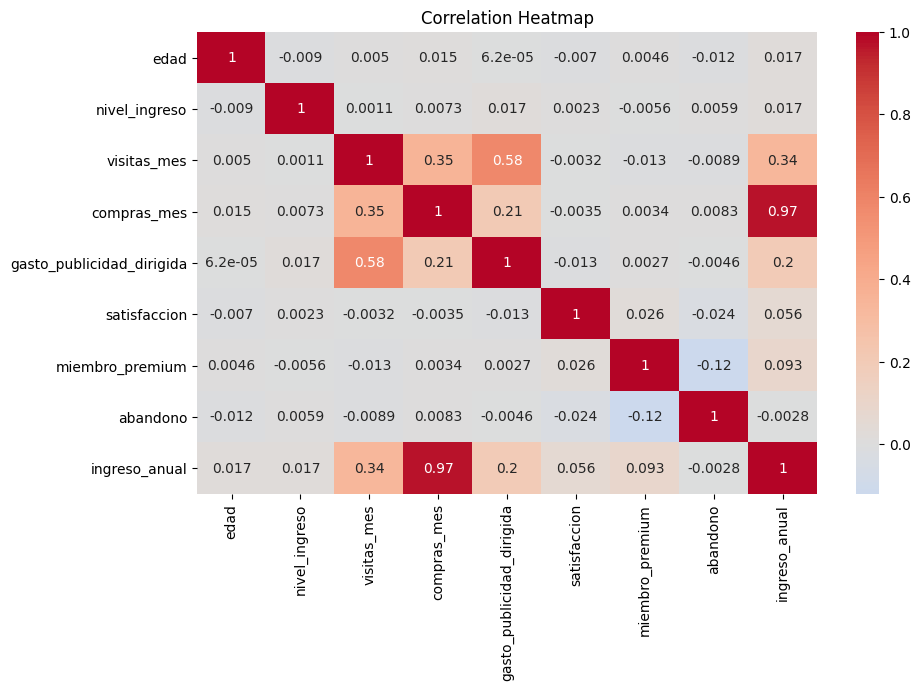

In [59]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df.corr()
plt.figure (figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm",center=0)
plt.title("Correlation Heatmap")
plt.show()

✍️ **Observaciones**: 


Observaciones generales (Heatmap)  
- Se observa que el mapa de calor revela un escenario donde predomina la ausencia de relaciones lineales significativas entre la mayoría de las variables, destacando coeficientes cercanos a cero en dimensiones clave como la edad, el nivel de ingreso personal y la satisfacción del cliente. Las únicas asociaciones relevantes corresponden a comportamientos de navegación y marketing; específicamente, se observa una correlación positiva moderada entre el gasto en publicidad dirigida y las visitas mensuales (0.58), así como un vínculo más tenue pero directo entre la frecuencia de estas visitas y el volumen de compras (0.35), lo que evidencia que la actividad dentro de la plataforma y los estímulos publicitarios tienden a desplazarse en una misma dirección lineal.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva casi perfecta y altamente colineal con las compras mensuales (0.97), indicando que ambas métricas comparten un comportamiento prácticamente idéntico dentro del conjunto de datos. Asimismo, muestra una asociación positiva débil con las visitas al mes (0.34) y el presupuesto publicitario asignado (0.20), lo que refleja que los clientes de mayor facturación anual coinciden simultáneamente con perfiles de alta interacción y exposición a campañas. Por el contrario, su relación estadística es nula frente a características socioeconómicas o de percepción, demostrando que el volumen de ingresos que percibe la empresa por usuario no está vinculado linealmente a la edad, los ingresos propios del cliente ni a su nivel declarado de satisfacción.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

### Scatterplot para pares clave

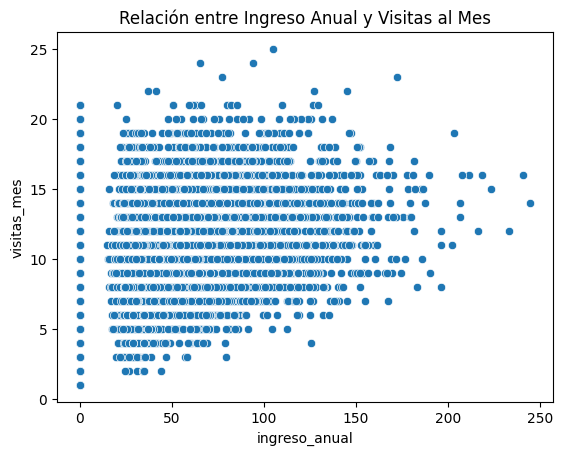

In [60]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='ingreso_anual', y='visitas_mes')
plt.title('Relación entre Ingreso Anual y Visitas al Mes')
plt.show()

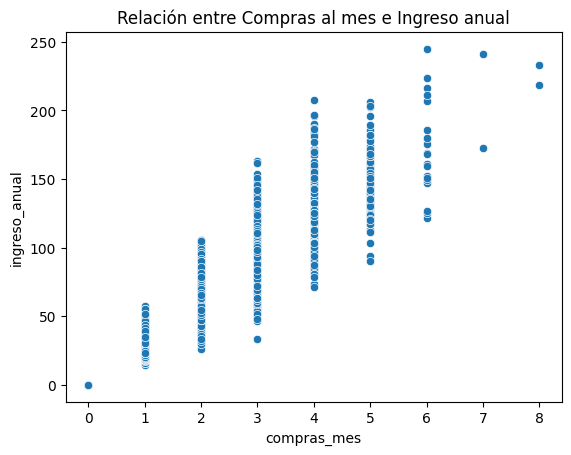

In [61]:
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
plt.title('Relación entre Compras al mes e Ingreso anual')
plt.show()

✍️ **Observaciones iniciales (Scatterplot)**

**Ingreso Anual vs Visitas Mes**
- Presentan una relación lineal positiva de fuerza débil a moderada (coeficiente de Pearson de 0.34). Se observa que los usuarios con mayor frecuencia de visitas mensuales tienden de manera general a registrar niveles de ingreso anual más altos para la empresa, aunque la tendencia es sutil y está lejos de ser una regla perfecta.
- El gráfico adopta una forma de "nube" con una dispersión amplia. Destaca una columna vertical muy marcada en el extremo izquierdo sobre el valor de ingreso anual cero (\(0\)), que representa a usuarios con múltiples visitas pero que no generaron facturación. No se observa colinealidad. Los datos extremos u outliers visibles (como usuarios con más de 20 visitas pero ingresos bajos, o clientes de alta facturación con visitas moderadas) son registros completamente válidos y naturales del comportamiento del consumidor en el e-commerce, por lo que no requieren ser eliminados del dataset.

**Compras Mes vs Ingreso Anual**
- Presentan una relación lineal positiva extremadamente fuerte. A medida que se registra un mayor número de compras mensuales por parte del usuario, se observa un incremento directo, marcado y lineal en el ingreso anual percibido por el e-commerce.
- Los puntos se agrupan en columnas verticales paralelas debido a la naturaleza discreta de compras_mes (valores enteros). Sin embargo, a diferencia de otros cruces, la dispersión vertical está muy acotada y compacta, confirmando visualmente la colinealidad casi perfecta (0.97) calculada en el heatmap. No se observan outliers anómalos o fuera de la tendencia diagonal, validando que el comportamiento de facturación de los clientes de alto valor ("heavy buyers") es sumamente consistente con su volumen transaccional.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [62]:
# Calcular correlación entre variables relevantes
variables_clave = ["ingreso_anual", "compras_mes", "visitas_mes"]
print("--- MATRIZ DE PEARSON ---")
print(df[variables_clave].corr(method="pearson"))

--- MATRIZ DE PEARSON ---
               ingreso_anual  compras_mes  visitas_mes
ingreso_anual       1.000000     0.967149     0.337147
compras_mes         0.967149     1.000000     0.353844
visitas_mes         0.337147     0.353844     1.000000


In [63]:
# Calcular correlación entre variables relevantes

variables_clave = ["ingreso_anual", "compras_mes", "visitas_mes"]
print("\n--- MATRIZ DE SPEARMAN ---")
print(df[variables_clave].corr(method="spearman"))


--- MATRIZ DE SPEARMAN ---
               ingreso_anual  compras_mes  visitas_mes
ingreso_anual       1.000000     0.967482     0.320954
compras_mes         0.967482     1.000000     0.332943
visitas_mes         0.320954     0.332943     1.000000


✍️ **Observaciones de correlación**


### Análisis Comparativo de Correlación: Pearson vs. Spearman

Para garantizar la comparabilidad de los métodos analíticos y evaluar el comportamiento de la variable central del proyecto (`ingreso_anual`), se generaron ambas matrices de correlación utilizando exactamente el mismo conjunto de variables continuas y discretas.

#### 1. Par Central: `compras_mes` vs `ingreso_anual`
* **Resultados**: Pearson = **0.9671** | Spearman = **0.9675**
* **Análisis comparativo**: La coincidencia casi exacta entre ambos coeficientes (una diferencia menor a 0.001) confirma de forma robusta que existe una relación monótona lineal casi perfecta. Esto ratifica un escenario de alta colinealidad: el volumen de ingresos anuales generados se desplaza en una proporción constante respecto a las transacciones mensuales, lo que convierte a estas métricas en técnicamente redundantes para propósitos de modelado predictivo.

#### 2. Par de Interacción: `visitas_mes` vs `ingreso_anual`
* **Resultados**: Pearson = **0.3371** | Spearman = **0.3210**
* **Análisis comparativo**: Ambos métodos identifican una asociación positiva de magnitud débil a moderada. Al aplicar Spearman por rangos, el coeficiente disminuye levemente en comparación con Pearson. Esta variación demuestra que la relación lineal directa pierde un poco de consistencia en ciertos rangos de datos, indicando que el incremento en el tráfico del sitio web no se traduce de manera uniforme ni escalonada en un mayor valor de facturación anual acumulada para todos los perfiles de clientes.

#### 3. Par Transaccional: `compras_mes` vs `visitas_mes`
* **Resultados**: Pearson = **0.3538** | Spearman = **0.3329**
* **Análisis comparativo**: Muestra un comportamiento análogo al par anterior, con una asociación positiva moderada-débil. La reducción del coeficiente en el análisis de Spearman refleja el impacto que tiene la naturaleza discreta y vertical de la variable `compras_mes`. Estadísticamente se confirma de forma homogénea que una mayor navegación tiende a coincidir con más compras, pero con una dispersión amplia que valida la independencia informativa entre la frecuencia de visitas y el cierre efectivo de la transacción.

### Punto-biserial

In [64]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df["miembro_premium"],df["ingreso_anual"])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [65]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df["abandono"],df["ingreso_anual"])

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

✍️ **Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**
- Muestra una dirección positiva y una magnitud baja (coeficiente ≈ 0.0931). Estadísticamente indica que los clientes con suscripción premium (1) tienden a registrar ingresos anuales marginalmente mayores para el e-commerce en comparación con los no premium, aunque la fuerza de la asociación es muy débil. Sin embargo, el valor p extremadamente pequeño (3.09 × 10⁻³⁰) confirma que esta relación, aunque pequeña, es estadísticamente significativa y no se debe al azar.

**abandono vs ingreso_anual**
- Presenta un coeficiente punto-biserial de **-0.0028**. La dirección es negativa, pero la magnitud es prácticamente cero, lo que clasifica formalmente la fuerza de la asociación como completamente nula o inexistente.
- A diferencia de otros cruces, el valor p obtenido es extremadamente alto (**0.7295**). Al ser un valor muy superior al umbral estándar de significancia alpha (p > 0.05), se concluye que **no existe evidencia estadística suficiente para afirmar una relación** entre el estado de abandono del cliente y la facturación anual que este generaba. La pequeña variación negativa observada se debe meramente al azar.
- Estadísticamente, el riesgo de deserción o abandono (Churn) se distribuye de manera completamente homogénea y aleatoria a lo largo de todos los niveles de facturación anual, afectando por igual tanto a compradores casuales de bajo valor como a los clientes de alta facturación ("heavy buyers"). Esto exige que los esfuerzos de retención no se segmenten únicamente por valor de compra, sino por patrones de comportamiento o interacción digital.

### V de Cramér

In [66]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
vars_cramer = ["tipo_dispositivo", "region", "abandono", "miembro_premium"]

In [67]:
# Aplicar V de Cramér en variables relevantes

def calcular_cramers_v(var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    # Cambiado 'df' por 'dof' para proteger la base de datos
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return cramers_v

matriz_cramer = pd.DataFrame(index=vars_cramer, columns=vars_cramer, dtype=float)

for v1 in vars_cramer:
    for v2 in vars_cramer:
        if v1 == v2:
            matriz_cramer.loc[v1, v2] = 1.0
        else:
            matriz_cramer.loc[v1, v2] = calcular_cramers_v(v1, v2)

# Mostrar la matriz completa con todos los pares evaluados
print("--- MATRIZ COMPLETA DE V DE CRAMÉR ---")
print(matriz_cramer.round(4))



--- MATRIZ COMPLETA DE V DE CRAMÉR ---
                  tipo_dispositivo  region  abandono  miembro_premium
tipo_dispositivo            1.0000  0.0124    0.0072           0.0197
region                      0.0124  1.0000    0.0154           0.0126
abandono                    0.0072  0.0154    1.0000           0.1202
miembro_premium             0.0197  0.0126    0.1202           1.0000


✍️ **Observaciones V de Cramér**: 
#### 1. Cruce entre Variables Categóricas (`tipo_dispositivo` vs `region`)
* **Resultado**: El coeficiente registra un valor de **0.0124**, ratificando una asociación nula. La distribución geográfica de los usuarios no ejerce ninguna influencia estadística medible sobre la preferencia del entorno tecnológico o dispositivo de navegación utilizado.

#### 2. Cruce de Variables Categóricas vs. Binarias de Negocio
* **Resultados**: 
  * `tipo_dispositivo` vs `abandono` = **0.0072**
  * `tipo_dispositivo` vs `miembro_premium` = **0.0197**
  * `region` vs `abandono` = **0.0154**
  * `region` vs `miembro_premium` = **0.0126**
* **Diagnóstico**: Todos los cruces registran coeficientes despreciables (valores muy cercanos a 0.0). Esto demuestra con rigor matemático que las métricas operativas clave del e-commerce (la conversión a membresías de pago y la tasa de deserción de la plataforma) son completamente independientes del origen demográfico del cliente y del dispositivo tecnológico desde el cual interactúa.

#### 3. Cruce entre Variables Binarias (`abandono` vs `miembro_premium`)
* **Resultado**: El coeficiente arroja un valor de **0.1202**. Aunque sigue clasificándose como una asociación débil, es notablemente el coeficiente más alto de toda la matriz cualitativa. Esto valida estadísticamente que existe una pequeña estructura de dependencia no lineal entre poseer una suscripción activa y la probabilidad de permanencia del cliente en el e-commerce, consistente con los análisis descriptivos previos.

#### Implicación de Negocio
La ausencia generalizada de asociaciones significativas entre estos bloques cualitativos simplifica drásticamente las estrategias operativas de mercadeo y producto. El e-commerce puede desplegar esfuerzos homogéneos de retención de clientes y campañas de conversión Premium a nivel nacional, omitiendo la necesidad de segmentar o fragmentar los presupuestos de comunicación por tipo de dispositivo o por zonas geográficas específicas.


## Analisis Visual

### Boxplots

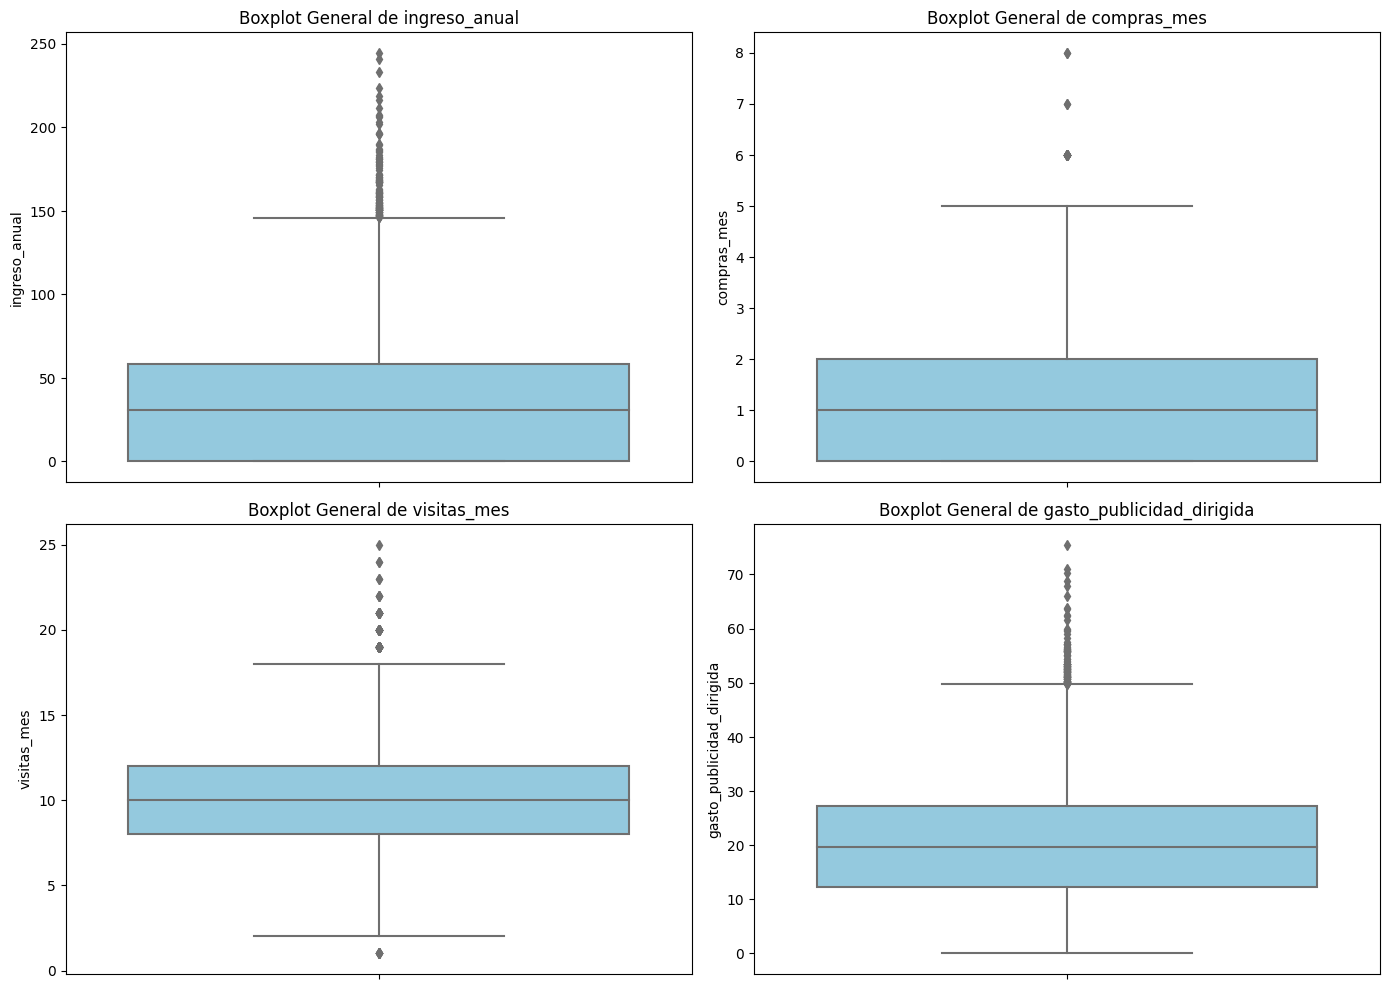

In [68]:
variables_box = [
    "ingreso_anual",
    "compras_mes",
    "visitas_mes",
    "gasto_publicidad_dirigida",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variables_box):
    sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot General de {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Análisis de Distribución e Identificación de Valores Atípicos (Boxplots)

Se generaron gráficos de caja generales para las cuatro variables numéricas seleccionadas (`ingreso_anual`, `compras_mes`, `visitas_mes` y `gasto_publicidad_dirigida`). El análisis visual revela que las cuatro dimensiones presentan valores atípicos (*outliers*) en sus extremos superiores, lo que refleja un comportamiento transaccional y de navegación con colas pesadas.

#### 1. Variable: `ingreso_anual`
* **Forma de la distribución**: Presenta una dispersión moderada en su rango intercuartílico (la caja va de 0 a aproximadamente 60), con una mediana cercana a 30. Muestra una asimetría positiva hacia los valores altos.
* **Identificación de Outliers**: **Sí presenta valores atípicos de forma masiva**. Se observa una densa hilera vertical de puntos negros que inicia justo arriba de 145 y se extiende de manera continua hasta alcanzar un máximo cercano a 250. Representan el segmento de clientes de élite o de mayor facturación acumulada para la empresa.

#### 2. Variable: `compras_mes`
* **Forma de la distribución**: Al ser una variable discreta, los cuartiles se fijan en valores enteros exactos (Q1=0, Mediana=1, Q3=2). El bigote superior se extiende formalmente hasta el valor de 5 compras al mes.
* **Identificación de Outliers**: **Sí presenta valores atípicos discretos**. Se identifican únicamente tres niveles de registros anómalos bien definidos en la parte superior: usuarios que realizaron exactamente 6, 7 y 8 compras en el mes. Son clientes con una frecuencia de conversión inusualmente alta dentro de la plataforma.

#### 3. Variable: `visitas_mes`
* **Forma de la distribución**: Muestra una estructura bastante balanceada y simétrica dentro de la caja (concentrada entre 8 y 12 visitas mensuales), con una línea de mediana perfectamente centrada en el valor de 10. Su bigote superior llega de forma normal hasta las 18 visitas.
* **Identificación de Outliers**: **Sí presenta valores atípicos**. Contrario a una distribución normal pura, el gráfico expone una serie de puntos aislados en el extremo superior que abarcan desde las 19 hasta las 25 visitas al mes, identificando a los usuarios más conectados o expuestos a la interfaz del sitio.

#### 4. Variable: `gasto_publicidad_dirigida`
* **Forma de la distribución**: La caja se ubica principalmente en la parte inferior del gráfico (rango intercuartílico entre 12 y 28 aproximadamente), con una mediana cercana a 20, lo que denota que la mayoría de los usuarios reciben una inversión publicitaria moderada. Su límite superior normal se indexa en 50.
* **Identificación de Outliers**: **Sí presenta valores atípicos de forma masiva**. Se aprecia una acumulación densa y compacta de puntos negros que inicia en el umbral de 50 y escala verticalmente hasta rozar el valor de 75. Esto evidencia la existencia de un subgrupo específico de clientes sobre los cuales el e-commerce realiza un esfuerzo de inversión publicitaria dirigida excepcionalmente alto.

### Pairplot / Scatterplot matrix

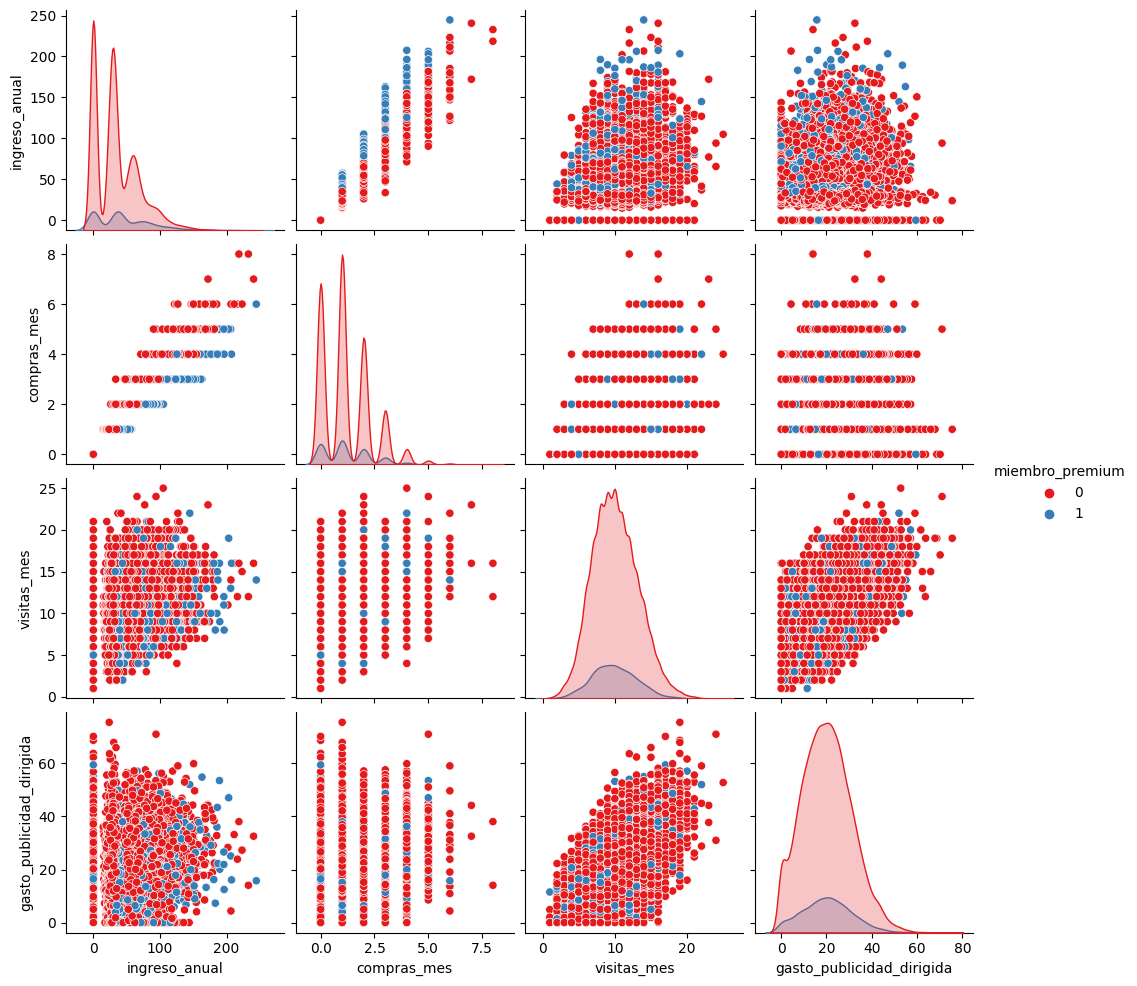

In [69]:
variables_pair = [
    "ingreso_anual",
    "compras_mes",
    "visitas_mes",
    "gasto_publicidad_dirigida",
]

sns.pairplot(df[variables_pair + ["miembro_premium"]], hue="miembro_premium", palette="Set1")
plt.show()

### Análisis Simultáneo (Matriz Pairplot)

Se ejecutó una matriz de gráficos de dispersión (`sns.pairplot`) restringida al conjunto de las cuatro variables numéricas clave (`ingreso_anual`, `compras_mes`, `visitas_mes` y `gasto_publicidad_dirigida`), utilizando la condición de `miembro_premium` como variable de matiz cromático (Rojo = 0, Azul = 1). Esta visualización consolida de forma integrada las densidades individuales y las relaciones cruzadas de la muestra.

#### 1. Diagnóstico de las Diagonales (Distribuciones de Densidad)
* **Observaciones**: Los gráficos de densidad de la diagonal principal exponen visualmente la asimetría en el tamaño de las subpoblaciones del e-commerce. La curva de densidad de los usuarios estándar (rojo) exhibe una altura y volumen marcadamente superiores en todas las dimensiones, reflejando que constituyen la gran mayoría de la base de datos. Al observar el eje horizontal de `ingreso_anual` y `compras_mes`, la curva de los usuarios Premium (azul) se presenta como una distribución más baja en volumen absoluto pero con un sutil desplazamiento de su concentración hacia la derecha en comparación con el pico del segmento regular. Esto resulta visualmente coherente con los estadísticos agregados del proyecto, donde el grupo Premium registra promedios de facturación más altos, a pesar de representar un segmento compacto y proporcionalmente menor en la muestra global.

#### 2. Validación de Relaciones Críticas y Estructuras Gráficas
* **Cruce `compras_mes` vs `ingreso_anual`**: Se aprecia una alineación diagonal ascendente casi perfecta, estructurada en columnas paralelas por la naturaleza discreta de las compras. La dispersión es mínima y ambos colores se entremezclan a lo largo de la franja diagonal. Esto ratifica visualmente la colinealidad extrema (0.97) diagnosticada numéricamente; ambas variables capturan exactamente la misma variabilidad del negocio.
* **Cruce `gasto_publicidad_dirigida` vs `visitas_mes`**: Los cuadrantes correspondientes muestran una nube de puntos densa con una inclinación positiva moderada muy clara. El sombreado azul se concentra de manera uniforme en el centro de esta nube, evidenciando que la estrategia de publicidad dirigida hacia los usuarios Premium mantiene una asignación estándar (entre 10 y 40 unidades de gasto) que se traduce en un tráfico regular (entre 5 y 15 visitas mensuales), sin registrar picos anómalos.
* **Cruces Restantes**: Los gráficos que involucran `visitas_mes` e `ingreso_anual` adoptan formas piramidales o de nubes dispersas, confirmando de manera visual la ausencia de relaciones lineales fuertes o patrones no lineales ocultos (como curvas cuadráticas o parábolas).

### Analisis por segmentos

In [70]:
# 1. Segmentación por Tipo de Cliente (Premium vs. No Premium)
print("--- SEGMENTACIÓN POR TIPO DE CLIENTE ---")
print(df.groupby('miembro_premium')[['ingreso_anual', 'abandono']].mean())

# 2. Segmentación por Región Geográfica
print("\n--- SEGMENTACIÓN POR REGIÓN ---")
print(df.groupby('region')[['ingreso_anual', 'abandono']].mean())

# 3. Segmentación por Entorno Tecnológico (Tipo de Dispositivo)
print("\n--- SEGMENTACIÓN POR TIPO DE DISPOSITIVO ---")
print(df.groupby('tipo_dispositivo')[['ingreso_anual', 'abandono']].mean())

--- SEGMENTACIÓN POR TIPO DE CLIENTE ---
                 ingreso_anual  abandono
miembro_premium                         
0                    35.302810  0.168074
1                    44.575452  0.043562

--- SEGMENTACIÓN POR REGIÓN ---
        ingreso_anual  abandono
region                         
este        36.893930  0.146953
norte       36.711065  0.144255
oeste       35.720438  0.157480
sur         37.102853  0.154589

--- SEGMENTACIÓN POR TIPO DE DISPOSITIVO ---
                  ingreso_anual  abandono
tipo_dispositivo                         
escritorio            36.423516  0.153495
móvil                 36.588418  0.148910
tablet                37.067120  0.155951


### Análisis Descriptivo por Segmentos de Negocio 

Con el objetivo de contrastar numéricamente el comportamiento de la variable central (`ingreso_anual`) y la métrica de retención (`abandono`), se realizaron segmentaciones basadas en las dimensiones cualitativas del conjunto de datos: tipo de cliente, región geográfica y entorno tecnológico.

#### 1. Segmento: Clientes Premium vs. No Premium
* **Comportamiento Observado**: Al agrupar los datos por la condición de membresía, se detecta un contraste claro en ambas dimensiones analíticas. El subgrupo de clientes Premium (1) registra simultáneamente un promedio de facturación anual más alto (44.58 unidades en comparación con las 35.30 del segmento regular) y una tasa de deserción marcadamente inferior (4.36% frente a 16.81%). 
* **Diagnóstico**: Estos estadísticos demuestran que el perfil Premium se asocia de manera consistente con un rendimiento financiero superior y una estabilidad de permanencia drásticamente mayor en la plataforma.

#### 2. Segmento: Distribución por Región Geográfica
* **Comportamiento Observado**: El desglose por zonas territoriales revela un escenario de homogeneidad absoluta. El ingreso anual promedio fluctúa de forma muy estrecha entre las regiones (variando sutilmente desde 35.72 en el oeste hasta 37.10 en el sur). De manera idéntica, la proporción de abandono se mantiene sumamente estable, oscilando entre el 14.43% (norte) y el 15.75% (oeste).
* **Diagnóstico**: La paridad en estos promedios y proporciones ratifica numéricamente la independencia geográfica que ya sugería el coeficiente V de Cramér (0.0154). El comportamiento de compra y los riesgos de pérdida de clientes se distribuyen uniformemente en el territorio.

#### 3. Segmento: Entorno Tecnológico (Tipo de Dispositivo)
* **Comportamiento Observado**: Al inspeccionar los registros según el canal de navegación utilizado (escritorio, móvil, tablet), las métricas financieras promedio y las tasas de deserción permanecen prácticamente idénticas. El ingreso anual ronda los 36.42 y 37.07 unidades para todos los canales, mientras que el abandono se estabiliza de forma simétrica entre el 14.89% (móvil) y el 15.60% (tablet).
* **Diagnóstico**: El entorno tecnológico de acceso actúa como una dimensión independiente frente al rendimiento de la facturación y la tasa de retención. Los usuarios interactúan y transaccionan con intensidades proporcionales sin verse condicionados estadísticamente por la pantalla o la interfaz elegida.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Relación lineal extrema entre transacciones y facturación anual

* **Evidencia visual**: En el Heatmap, la celda que cruza la fila de `compras_mes` con la columna de `ingreso_anual` se muestra con un tono rojo intenso uniforme y brillante. Este color se ubica en el extremo superior de la escala de la barra de referencia lateral (1.0), lo que delata visualmente una dependencia lineal muy fuerte frente al comportamiento neutral y grisáceo del resto de la matriz.
* **Evidencia numérica**: El coeficiente de correlación de Pearson entre las variables `compras_mes` e `ingreso_anual` registra un valor de **0.97**. Al estar extremadamente cercano a 1.0, confirma matemáticamente una correlación positiva casi perfecta entre ambas dimensiones.

### Interpretación
El resultado demuestra que ambas variables se desplazan de manera prácticamente idéntica dentro del conjunto de datos. A medida que aumenta el volumen de transacciones mensuales completadas por un usuario, el ingreso anual que la empresa percibe por ese mismo cliente se incrementa en una proporción fija y constante, exhibiendo una estructura matemática altamente predecible.

### No podemos afirmar
Debido a las limitaciones del análisis estadístico correlacional, **no podemos afirmar una relación de causalidad directa**, es decir, que el hecho de registrar más compras sea la causa única u origen del volumen de facturación anual. Tampoco se puede asumir que forzar un incremento artificial en el conteo de compras de un usuario casual vaya a transformarlo automáticamente en un cliente de alto valor permanente si no se consideran de forma integral otras dimensiones comerciales.

### Implicación de negocio
Para el e-commerce, esta fortísima asociación lineal indica que la salud financiera a largo plazo del negocio está directamente ligada a la actividad transaccional del mes a mes. Estratégicamente, el negocio debe enfocar sus esfuerzos comerciales en diseñar incentivos que aumenten de forma sostenida la frecuencia de compra de los usuarios actuales (como programas de recompensas por recurrencia, suscripciones de reposición automática o promociones personalizadas basadas en el historial del cliente), garantizando así un incremento predecible y robusto en los ingresos anuales acumulados por la empresa.





### Hallazgo 2 — Relación entre la frecuencia de visitas mensuales y la facturación anual

* **Evidencia visual**: En el gráfico de dispersión, los datos se distribuyen en forma de una nube de puntos amplia y dispersa que exhibe una sutil inclinación positiva ascendente de izquierda a derecha. Destaca una concentración densa de registros en la base inferior del gráfico, así como la presencia de usuarios con una frecuencia de visitas muy alta pero cuyos ingresos anuales permanecen en niveles intermedios o bajos.
* **Evidencia numérica**: Basado en las matrices de correlación calculadas, este cruce registra un coeficiente lineal de Pearson de **0.3371** y un coeficiente por rangos de Spearman de **0.3210**, consolidando de manera formal una asociación positiva de magnitud débil a moderada.

### Interpretación
El análisis revela una tendencia general donde una mayor frecuencia de visitas mensuales por parte de los usuarios coincide de forma directa con niveles de ingreso anual más altos para la empresa. Sin embargo, la amplia dispersión de la nube de puntos demuestra que el tráfico constante en la plataforma es un comportamiento variable que no asegura de forma rígida una escala proporcional de facturación acumulada para todos los perfiles de clientes.

### No podemos afirmar
A nivel metodológico, **no podemos afirmar una relación de causalidad**. No se puede concluir que la implementación de estrategias dirigidas puramente a forzar o inducir un mayor volumen bruto de visitas o sesiones (como el envío masivo de notificaciones o alertas) vaya a actuar como el detonante causal que incremente de forma directa la facturación anual de un usuario. Asimismo, la baja magnitud de la correlación impide asegurar que un cliente con interacciones moderadas en el sitio web tenga un valor financiero importante a largo plazo.

### Implicación de negocio
Para el e-commerce, este hallazgo es clave para orientar la estrategia de retención y optimización del tráfico. Debido a que el incremento en las visitas se asocia con mayores ingresos pero con un margen de dispersión amplio, el negocio no debe centrar sus inversiones únicamente en métricas de volumen bruto de visitas de forma aislada. Estratégicamente, el equipo comercial debe priorizar iniciativas enfocadas en aumentar el valor promedio de cada sesión (como la personalización del catálogo en tiempo real, recomendaciones inteligentes de productos complementarios o mejoras de usabilidad en el proceso de pago), logrando de esta manera capitalizar de forma efectiva el flujo de interacción digital actual y traducirlo en un mayor valor de facturación anual acumulada.


### Hallazgo 3 — Impacto del estado de membresía sobre el rendimiento de la facturación anual

* **Evidencia visual**: En el gráfico de densidad marginal del Pairplot, la distribución de los usuarios Premium (1) muestra una concentración compacta y un sutil desplazamiento hacia el extremo de mayor valor del eje de ingresos, en comparación con la curva de volumen masivo pero de menor promedio de los usuarios estándar (0).
* **Evidencia numérica**: El cálculo del coeficiente de correlación Punto-biserial arroja un valor positivo de **0.0931**. Si bien la magnitud lineal es baja, el análisis de segmentación complementario revela que el promedio real de facturación anual de un miembro Premium es de **44.58 unidades**, superando de manera contundente las **35.30 unidades** que promedia un cliente regular. Además, el valor p extremadamente pequeño ($3.09 \times 10^{-30}$) confirma que esta diferencia es estadísticamente significativa y no es producto del azar.

### Interpretación
Los resultados estadísticos demuestran de forma consistente que pertenecer al segmento Premium se asocia con un rendimiento financiero anual superior para la empresa. Aunque el coeficiente correlacional general parece atenuado debido a que los miembros Premium son una subpoblación minoritaria en la muestra, la comparación agregada de medias confirma que este grupo genera un valor económico promedio notablemente más alto que los clientes estándar.

### No podemos afirmar
A nivel metodológico, **no podemos afirmar una relación de causalidad**. No se puede concluir que el simple acto administrativo de otorgarle una membresía de pago a un usuario vaya a provocar de manera automática que este empiece a gastar más dinero en la plataforma. Es altamente probable que la relación esté mediada por un comportamiento de autoselección, donde los clientes que ya poseían una alta afinidad y recurrencia de compra previa en el e-commerce sean los mismos que deciden suscribirse al programa Premium.

### Implicación de negocio
Para el e-commerce, este hallazgo resalta el alto valor comercial que representa la conversión de la base de usuarios. Dado que el segmento Premium se asocia de forma tan sólida con una mayor facturación anual promedio y con tasas de abandono mínimas, la estrategia de crecimiento no debe limitarse a la captación de tráfico masivo externo. Estratégicamente, la empresa debe priorizar campañas de mercadeo relacional e incentivos de conversión interna para motivar a los clientes regulares con perfiles de compra intermedios a dar el salto al modelo Premium (por ejemplo, ofreciendo meses de prueba gratuitos, envíos sin costo exclusivos o acceso anticipado a lanzamientos), logrando así elevar el valor de vida del cliente (LTV) y estabilizar los ingresos recurrentes del negocio.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- No podemos afirmar una relación de causalidad directa entre variables como compras_mes vs ingreso_anual o visitas_mes vs compras_mes
- Registros de fechas para trazabilidad de clientes activos y abandonos, esto limita la creacion de modelos predictivos 
- Sesgo marcado hacia la derecha en Ingreso_Anual
- No hay información sobre las razones por las que un cliente abandona la plataforma, lo que impide identificar los factores detonantes del churn.
  
### **Próximos pasos** 

Agregar registros de tiempo o fechas
- Fecha de suscripcion
- Fecha de abandono

Determinar razones de abandono
- Evaluar la razon mas frecuente
- Buscar posibles correlaciones

Explorar otras segmentaciones
- abandono vs satisfaccion
- miembro premium vs region